In [1]:
print("all ok")

all ok


In [2]:
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm=ChatGroq(model="deepseek-r1-distill-llama-70b")

In [6]:
print(llm.invoke("What is the capital of France?").content)

<think>

</think>

The capital of France is Paris.


In [7]:
print(llm.invoke("What is the capital of india tell me in detail?").content)

<think>
Okay, so I need to figure out the capital of India and provide a detailed explanation. Hmm, I'm pretty sure the capital isn't Mumbai because I remember hearing that Mumbai is a major city but not the capital. I think the capital is New Delhi. Yeah, that sounds right. But wait, sometimes people confuse Delhi and New Delhi. Are they the same thing?

Let me think. I believe Delhi is a state or a union territory, and within it is New Delhi, which is the actual capital. So, the capital isn't just Delhi; it's specifically New Delhi. Got it. Now, to provide a detailed answer, I should probably explain more about New Delhi's significance, its history, and maybe some key landmarks.

New Delhi was built by the British, right? I think they moved the capital from Calcutta to New Delhi in 1911. The construction was led by Edwin Lutyens and Herbert Baker. They designed it with broad avenues and monumental buildings. That's why New Delhi has such a different look compared to Old Delhi.

Key l

In [8]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [9]:
search_tool.invoke("What is the capital of France?")

[{'title': 'What are the three official capitals of France and which one ... - Quora',
  'url': 'https://www.quora.com/What-are-the-three-official-capitals-of-France-and-which-one-is-the-most-commonly-visited',
  'content': "What is the capital of France? What are some of its major cities?\n\nThe capital of France is Paris. It is not only the country's capital but also its largest city and a global center for art, culture, fashion, and cuisine. Paris is home to iconic landmarks such as the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées. [...] The capital of France is Paris. It is not only the country's capital but also its largest city and a global center for art, culture, fashion, and cuisine. Paris is home to iconic landmarks such as the Eiffel Tower, Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées.\n\nApart from Paris, France has several other major cities that are significant in terms of population, economy, history, and cultural importance. S

In [10]:
my_code = """
x=10
y=x+10
print(y)
"""

In [11]:
from langchain_experimental.utilities import PythonREPL

In [12]:
repl=PythonREPL()

In [13]:
repl.run(my_code) # provide code in string format

Python REPL can execute arbitrary code. Use with caution.


'20\n'

In [13]:
repl.invoke(my_code) # repl is not a langchain tool

AttributeError: 'PythonREPL' object has no attribute 'invoke'

In [14]:
from typing import Annotated # with this Annotated we can add metadata to the function parameters
from langchain_core.tools import tool
@tool
def python_repl_tool(code: Annotated[str, "The python code to execute to generate output."]):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return result_str

<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
<>:13: SyntaxWarning: invalid escape sequence '\`'
C:\Users\Artur Dragunov\AppData\Local\Temp\ipykernel_7364\3740586686.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
C:\Users\Artur Dragunov\AppData\Local\Temp\ipykernel_7364\3740586686.py:13: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"


In [15]:
python_repl_tool.invoke("x=10\ny=x+10\nprint(y)") # now we can use repl in langchain syntax with invoke

'Successfully executed:\n\\`\\`\\`python\nx=10\ny=x+10\nprint(y)\n\\`\\`\\`\nStdout: 20\n'

In [16]:
python_repl_tool.invoke(my_code)

'Successfully executed:\n\\`\\`\\`python\n\nx=10\ny=x+10\nprint(y)\n\n\\`\\`\\`\nStdout: 20\n'

### WE HAVE TWO SUB AGENT 
1. RESEARCHER- internet
2. CODER- executing the code

In [17]:
members=["researcher","coder"] # tavily is researcher and repl is a coder

In [18]:
members

['researcher', 'coder']

In [19]:
options = members+["FINISH"]

In [20]:
options

['researcher', 'coder', 'FINISH']

In [21]:
from typing import Literal

In [22]:
from typing_extensions import TypedDict

## There is no routing logic
### it is simply going to return the next candidate(next_agent)
### this next is containig the next candidate name

In [23]:
class Router(TypedDict):
    next: Literal['researcher', 'coder', 'FINISH']

In [24]:
from langgraph.graph import MessagesState,StateGraph,START, END

#### this is a messagesstate which we are loading from the langgraph(inbuilt message state)

In [25]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

##### this is how my state will be looking like for SUPERVISOR

Both Router and State have field next. But Router we need for structured output! And returned value will update the State in next

In [59]:
class State(MessagesState): # MessagesState is a base class for the state of the agent taken from langgraph. It already has a field for messages.
    # now we only need to add other fields we want. So, instead of creating from scratch, you can inherit from MessagesState.
    next:str
state={"messages": ["hi"], "next": "researcher"} # state will consist of messages (inherited from MessagesState) and next state to go to
#messages is a list of conversation history

In [60]:
system_prompt = f""""
You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.
"""

In [61]:
# system_prompt = f""""
# You are a supervisor, tasked with managing a conversation between the following workers: {members}. 
# Given the following user request, respond with the worker to act next. 
# Each worker will perform a task and respond with their results and status. 
# When finished, respond with FINISH.
# **Strict Guidelines:**
# if there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.
# """

#### you can try out with this prompt also

In [68]:
system_prompt = f"""
You are a supervisor managing a task delegation system with the following workers: {members}.

Your job is to decide which worker should act next based on the user’s input.

Guidelines:
- Carefully read the user’s message.
- If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.
- If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
- Do **not** invent tasks or assign actions unless the message clearly demands it.

Each worker will return results after completing their task.
Once all necessary tasks are completed, end the flow by responding with `FINISH`.

Be strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.
"""


In [62]:
print(system_prompt)

"
You are a supervisor, tasked with managing a conversation between the following workers: ['researcher', 'coder']. 
Given the following user request, respond with the worker to act next. 
Each worker will perform a task and respond with their results and status. 
When finished, respond with FINISH.



In [69]:
messages = [{"role": "system", "content": system_prompt},] + state["messages"]

In [70]:
messages

[{'role': 'system',
  'content': "\nYou are a supervisor managing a task delegation system with the following workers: ['researcher', 'coder'].\n\nYour job is to decide which worker should act next based on the user’s input.\n\nGuidelines:\n- Carefully read the user’s message.\n- If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.\n- If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.\n- Do **not** invent tasks or assign actions unless the message clearly demands it.\n\nEach worker will return results after completing their task.\nOnce all necessary tasks are completed, end the flow by responding with `FINISH`.\n\nBe strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.\n"},
 'hi']

[{'role': 'system',
  'content': '"\nYou are a supervisor, tasked with managing a conversation between the following workers: [\'researcher\', \'coder\']. \nGiven the following user request, respond with the worker to act next. \nEach worker will perform a task and respond with their results and status. \nWhen finished, respond with FINISH.\n**Strict Guidelines:**\nif there is any common messages like hi, hello, how are you, greetings etc then,respond with FINISH.\n'},
 'hi']

In [71]:
llm_with_structure_output=llm.with_structured_output(Router)

In [72]:
messages

[{'role': 'system',
  'content': "\nYou are a supervisor managing a task delegation system with the following workers: ['researcher', 'coder'].\n\nYour job is to decide which worker should act next based on the user’s input.\n\nGuidelines:\n- Carefully read the user’s message.\n- If the message clearly requires a specific action (e.g., search, compute, rewrite), assign it to the appropriate worker.\n- If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.\n- Do **not** invent tasks or assign actions unless the message clearly demands it.\n\nEach worker will return results after completing their task.\nOnce all necessary tasks are completed, end the flow by responding with `FINISH`.\n\nBe strict — if the message is casual, rhetorical, or lacks a clear task, reply with `FINISH`.\n"},
 'hi']

Below is example of what input supervisor gets and what output it produces

In [73]:
llm_with_structure_output.invoke(messages)

{'next': 'FINISH'}

#### This is my all three agents

In [35]:
from langgraph.types import Command

In [36]:
def supervisor_agent(state:State)->Command[Literal['researcher', 'coder', '__end__']]: # three options for finish
    
    # supervisor agent reads the conversation and decides which agent to go to next
    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    
    # llm will return a dictionary with the key "next" and the value is the next agent to go to or FINISH
    # {next: 'researcher'}
    llm_with_structure_output=llm.with_structured_output(Router)
    
    response=llm_with_structure_output.invoke(messages)
    
    #this is my response {'next': 'researcher'} -> caused by Router class
    # we then pass this "next" element to update "next" State
    
    #this is my next worker agent
    goto=response["next"]
    
    print("**********BELOW IS MY GOTO***************")
    
    print(goto)
    
    if goto == "FINISH": # if llm returns FINISH, we go to the end of the graph
        goto=END
    
    # class State(MessagesState):
    #   next:str
    # output of the state: state={"messages": ["hi"], "next": "researcher"}
    
    return Command(goto=goto, update={"next":goto}) # update next comes from State class

In [37]:
from langgraph.prebuilt import create_react_agent

In [38]:
from langchain_core.messages import AIMessage, HumanMessage

In [39]:
def research_agent(state: State) -> Command[Literal["supervisor"]]: # researchers ONLY LOOKS IN THE INTERNET, so available tool is search_tool
    
    research_agent = create_react_agent(llm, tools=[search_tool], prompt="You are a researcher. DO NOT do any math.")
    
    result=research_agent.invoke(state)
    
    return Command(
        update={
            "messages": [
                # research agent reads conversation (messages state) and appends its own message to it mentioning its name
                HumanMessage(content=result["messages"][-1].content, name="researcher") 
            ]
        },
        goto="supervisor", # NO MATTER WHAT THE RESULT IS, WE GO TO THE SUPERVISOR
    )
    

In [40]:
def coder_agent(state:State)->Command[Literal['supervisor']]: # using Command we do hand-off -> passing the state to the next agent
    code_agent=create_react_agent(llm,tools=[python_repl_tool], prompt="You are a coder. DO NOT do any research.")
    result=code_agent.invoke(state) # code agent reads the whole state (messages + authors) and returns a new state with the new message (python code)
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder") 
            ]
        },
        goto="supervisor",
    )
    

#### this is my orchestration flow with langgraph

In [41]:
graph=StateGraph(State)

In [42]:
graph.add_node("supervisor", supervisor_agent)

In [43]:
graph.add_node("researcher", research_agent)

In [44]:
graph.add_node("coder", coder_agent)

In [45]:
graph.add_edge(START, "supervisor") # the rest edges are added automatically using Command.goto

In [46]:
app=graph.compile()

In [47]:
from IPython.display import display,Image

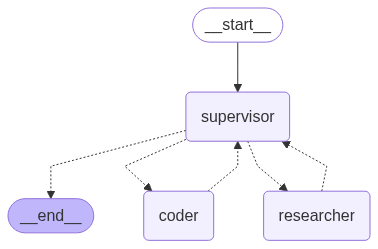

In [48]:
display(Image(app.get_graph().draw_mermaid_png()))

subgraph is the concept of hierarchical graphs. You have multiple layers, and each layer is a subgraph. So, if you want to see outputs of 
subgraphs, you need to mention that

![alt text](photo_2025-07-03_14-11-28.jpg)

In [51]:
for s in app.stream({"messages": [("user", "What's the square root of 42?")]}, subgraphs=True):
    print(s)
    print("**********BELOW IS MY STATE***************")

**********BELOW IS MY GOTO***************
researcher
((), {'supervisor': {'next': 'researcher'}})
**********BELOW IS MY STATE***************
(('researcher:3a42fa4b-f654-1e94-fbcb-b8a9f1c1caa7',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 's2p1n7cv2', 'function': {'arguments': '{"query":"square root of 42"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 323, 'prompt_tokens': 179, 'total_tokens': 502, 'completion_time': 1.40389853, 'prompt_time': 0.011251479, 'queue_time': 0.17647955599999998, 'total_time': 1.415150009}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_87ec4d1ec3', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--5d556300-3457-442a-8f2f-3ddce43974ae-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'square root of 42'}, 'id': 's2p1n7cv2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 179, '

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '\n\n{"type": "function", "name": "Router", "arguments": {"next": "researcher"}}'}}

In [50]:
result=app.invoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)

**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
coder
**********BELOW IS MY GOTO***************
researcher
**********BELOW IS MY GOTO***************
researcher


KeyboardInterrupt: 

In [131]:
result=app.ainvoke({"messages": [("user", "what is an efficent python code to get prime number?")]}, subgraphs=True)